# Throughput Monitor Lab

Explore `measure_throughput` with a fixed message pane and a live dashboard.
Run cells individually: setup, optional dark/calibration/manual work, then the throughput section.
The saved outputs and exploratory plots are historical lab observations, not current hardware status.

Use the workspace `.venv` kernel in JupyterLab. The dashboard uses `ipympl`
(`%matplotlib widget`), `ipywidgets`, and Matplotlib's normal toolbar and animation.
After installing ipympl, reload the JupyterLab page if the widget frontend is missing.

**Stop measurement / laser off** below stops the selected channel and explicitly
sets `LASER` to zero. Pausing or closing a display does not stop acquisition.
Laser-bank power and TECs remain available for temperature monitoring.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
import math
import time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

try:
    from scipy.optimize import least_squares
except ImportError:
    least_squares = None

import hispec_fibpcb as hspcb

BROKER = "hispec.caltech.edu"
LASER = "1028y"
OUTPUT = "yj_ao"
FIBER = "M"
PD_CHANNEL = "yj"


TAKE_DARK_HK=TAKE_DARK_YJ=True
DARK_DURATION_MS = 2000


FIRMWARE_CORRECTION_TERMS = hspcb.ATTENUATOR_MODEL_CORRECTION_TERMS
TX_MIN = hspcb.ATTEN_CAL_MIN_TX
TX_MAX = hspcb.ATTEN_CAL_MAX_TX
MAX_DAC_MV = hspcb.ATTENUATOR_DRIVE_MAX_MV
ADC_CLIP_MV = hspcb.ATTENUATOR_ADC_CLIP_MV
GAIN = hspcb.ATTENUATOR_DEFAULT_GAIN
FIT_MIN_SIGMA_DB = hspcb.ATTENUATOR_FIT_MIN_SIGMA_DB

pcb = hspcb.HispecFibPcb(BROKER, connect=True)


In [2]:
import asyncio
import logging
from collections import deque
import ipywidgets as widgets
from IPython.display import display
from html import escape

# Rerunning replaces only this pane and restores the prior client logger first.
if "message_task" in globals():
    message_task.cancel()
if "message_handler" in globals():
    message_client.logger = previous_logger
    message_logger.removeHandler(message_handler)
    message_handler.close()
    message_output.close()

class MessagePaneHandler(logging.Handler):
    """Buffer logs on the MQTT thread; widget updates belong to the kernel loop."""
    def __init__(self):
        super().__init__()
        self.lines = deque(maxlen=500)
        self.dirty = False

    def emit(self, record):
        # logging.Handler.handle holds this handler's lock during emit.
        try:
            self.lines.append(self.format(record) + "\n")
            self.dirty = True
        except Exception:
            self.handleError(record)

async def refresh_message_pane(handler, output):
    """Batch only changed log content at 2 Hz, independently of the plot timer."""
    while True:
        await asyncio.sleep(0.5)
        handler.acquire()
        try:
            if not handler.dirty:
                continue
            text = "".join(handler.lines)
            handler.dirty = False
        finally:
            handler.release()
        # output.outputs = ({"output_type": "stream", "name": "stdout", "text": text},)
        output.value = ('<pre style="margin:0; white-space:pre;">'
                        f'{escape(text)}'
                        '</pre>')


message_client = pcb
previous_logger = pcb.logger
message_logger = logging.Logger(f"throughput.lab.{pcb.device}", level=logging.DEBUG)
message_logger.propagate = False
# message_output = widgets.Output(layout={"height": "260px", "overflow": "auto",
#                                         "border": "1px solid #999"})

message_output = widgets.HTML(
    layout={
        "height": "260px",
        "overflow": "auto",
        "border": "1px solid #999",
        "display": "block",
    }
)
message_handler = MessagePaneHandler()
message_handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
message_logger.addHandler(message_handler)
pcb.logger = message_logger
message_task = asyncio.create_task(refresh_message_pane(message_handler, message_output))
display(message_output)

HTML(value='', layout=Layout(border_bottom='1px solid #999', border_left='1px solid #999', border_right='1px s…

In [3]:
pcb.status(), pcb.time()

(Status(
   fw='f578cbd0ae4d-dirty',
   boots=17,
   board='tib',
   board_ok=True,
   mems_switches=8,
   relay_err=0,
   amb_c=20.75,
   pd_on_s=117,
   laserbank_on_s=158,
   lastcmd=LastCommand(name='laser', src='mqtt', t_ms=52931),
   ip=None,
   lasers=(),
   attens=()
 ),
 TimeStatus(utc=1789584886314, uptime_s=159))

## Dark

Take or force the channel dark level here, then leave calibration to read the photodiode configuration.



In [4]:
pcb.pd()

PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=34,
  mv=2.125,
  net_mv=-40.1531,
  net_err_mv=209.653,
  power_uw=0,
  power_err_uw=1.12717e-05,
  dark_mv=42.2781,
  dark_err_mv=32.7423,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=1.8625,
  mean_net_mv=-40.4156,
  rms_mv=0.260408,
  mean_net_err_mv=73.214,
  min_mv=1.5,
  max_mv=2.375,
  power_uw=0,
  power_err_uw=3.93624e-06
),
  pd_powered=True,
  pd_on_s=122
),
  hk=PhotodiodeChannelValues(
  raw=14,
  mv=0.875,
  net_mv=-1.25937,
  net_err_mv=0.945083,
  power_uw=0,
  power_err_uw=1.63163e-06,
  dark_mv=2.13437,
  dark_err_mv=0.147597,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=0.81875,
  mean_net_mv=-1.31563,
  rms_mv=0.01875,
  mean_net_err_mv=0.330037,
  min_mv=0.8125,
  max_mv=0.875,
  power_uw=0,
  power_err_uw=5.69792e-07
),
  pd_powered=True,
  pd_on_s=0
)
)

In [110]:
persist=True
if TAKE_DARK_YJ:
    print('Initial', pcb.pd('yj'))
    pcb.pd_dark('yj', duration_ms=DARK_DURATION_MS, persist=persist)
time.sleep(DARK_DURATION_MS/1000+.1)
print(pcb.pd('yj'))
if TAKE_DARK_HK:
    print('Initial', pcb.pd('hk'))
    pcb.pd_dark('hk', duration_ms=DARK_DURATION_MS, persist=persist)
time.sleep(DARK_DURATION_MS/1000+.1)
print(pcb.pd('hk'))
pd_data = pcb.pd()
print(f"YJ dark: {pd_data.yj.dark_mv:.3f}±{pd_data.yj.dark_err_mv:.3f} mV\n"
      f"HJ dark: {pd_data.hk.dark_mv:.3f}±{pd_data.hk.dark_err_mv:.3f} mV")

Initial PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=23,
  mv=1.4375,
  net_mv=-0.685937,
  net_err_mv=0.443497,
  power_uw=0,
  power_err_uw=2.38439e-08,
  dark_mv=2.12344,
  dark_err_mv=0.0692626,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=1.75625,
  mean_net_mv=-0.367188,
  rms_mv=0.250702,
  mean_net_err_mv=0.154876,
  min_mv=1.4375,
  max_mv=2.25,
  power_uw=0,
  power_err_uw=8.32666e-09
),
  pd_powered=True,
  pd_on_s=4
),
  hk=None
)
PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=21,
  mv=1.3125,
  net_mv=-0.39375,
  net_err_mv=0.380238,
  power_uw=0,
  power_err_uw=2.04429e-08,
  dark_mv=1.70625,
  dark_err_mv=0.0593832,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=1.4375,
  mean_net_mv=-0.477344,
  rms_mv=0.316228,
  mean_net_err_mv=0.132785,
  min_mv=1,
  max_mv=2,
  power_uw=0,
  power_err_uw=7.13897e-09
),
  pd_powered=True,
  pd_on_s=7
),
  hk=None
)
Initial PhotodiodeValues(
  yj=None,
  hk=Ph

## Embedded Atten Auto-calibration

Run the on-board algorithm, then fetch metadata plus fixed raw-record chunks. The Python helper derives bridge scale, scaled signal, transmission, dB attenuation, fit inclusion, residuals, and role markers from those records.



In [111]:
embedded_status = pcb.atten_calibrate('1028y', output='yj_ao', fiber='M', dwell_ms=550, persist=True)
embedded_status


AttenuatorCalibrationStatus(
  state='running', mode='tib_auto', physical='dac1', point='1/128', complete_pct=0,
  mv=0, other_mv=3300, t_ms=550, error=0, fit='none',
  dac1=AttenuatorFitMetrics(valid=False),
  dac2=AttenuatorFitMetrics(valid=False)
)

In [112]:
pcb.atten_calibrate()


AttenuatorCalibrationStatus(
  state='complete', mode='tib_auto', physical='dac2', point='87/128', complete_pct=100,
  mv=2650, other_mv=2485.75, t_ms=550, error=0, fit='ok',
  dac1=AttenuatorFitMetrics(accepted=True, points=23, fvoa_50pct_mv=3357.43, slope_inv_fvoa_mv=0.00304484, max_atten_db=71.4409, max_atten_sigma_db=0.288675, corr=0.999576, rms_db=0.829763, max_abs_db=3.15758, correction_coeff=(-45.2037, -47.0846, -77.5625, -23.8789, -21.9807, -2.33944), fvoa_span_mv=1686.3),
  dac2=AttenuatorFitMetrics(accepted=True, points=20, fvoa_50pct_mv=3078.61, slope_inv_fvoa_mv=0.0031399, max_atten_db=33.8524, max_atten_sigma_db=2.0728, corr=0.997715, rms_db=0.910773, max_abs_db=3.99163, correction_coeff=(2.13492, 7.28444, 3.96896, 6.19004, 3.20024, 2.78903), fvoa_span_mv=2529.45)
)

In [113]:
pcb.laser('1028y', stop=True)
pcb.atten('1028y', value1_mv=3300, value2_mv=3300)
pcb.laser('1430hk', stop=True)
pcb.atten('1430hk', value1_mv=3300, value2_mv=3300)
embedded = pcb.atten_calibration_data(physical="all")


HispecFibPCBError: laser value failed

AttenuatorCalibrationDataset(
  records=208,
  physicals=('dac1', 'dac2'),
  counts=(('dac1', 106), ('dac2', 102))
)


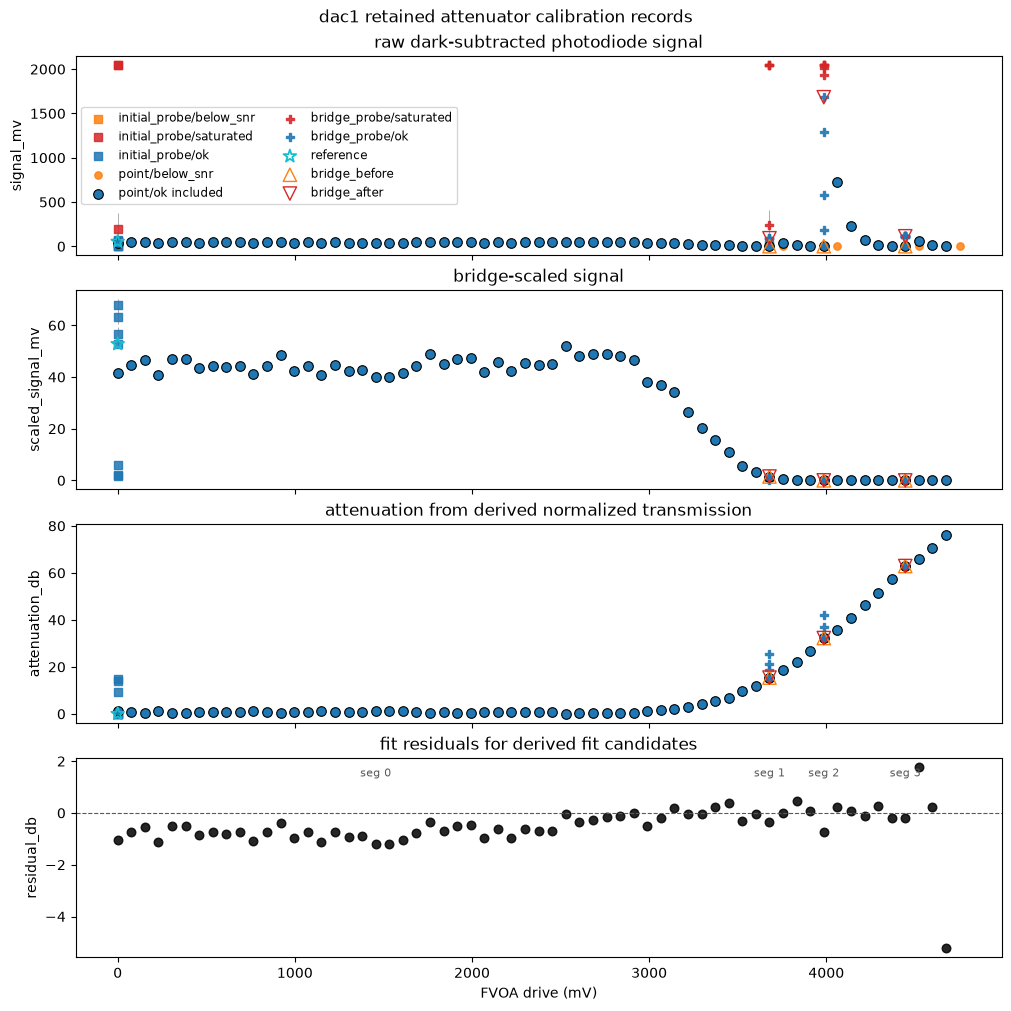

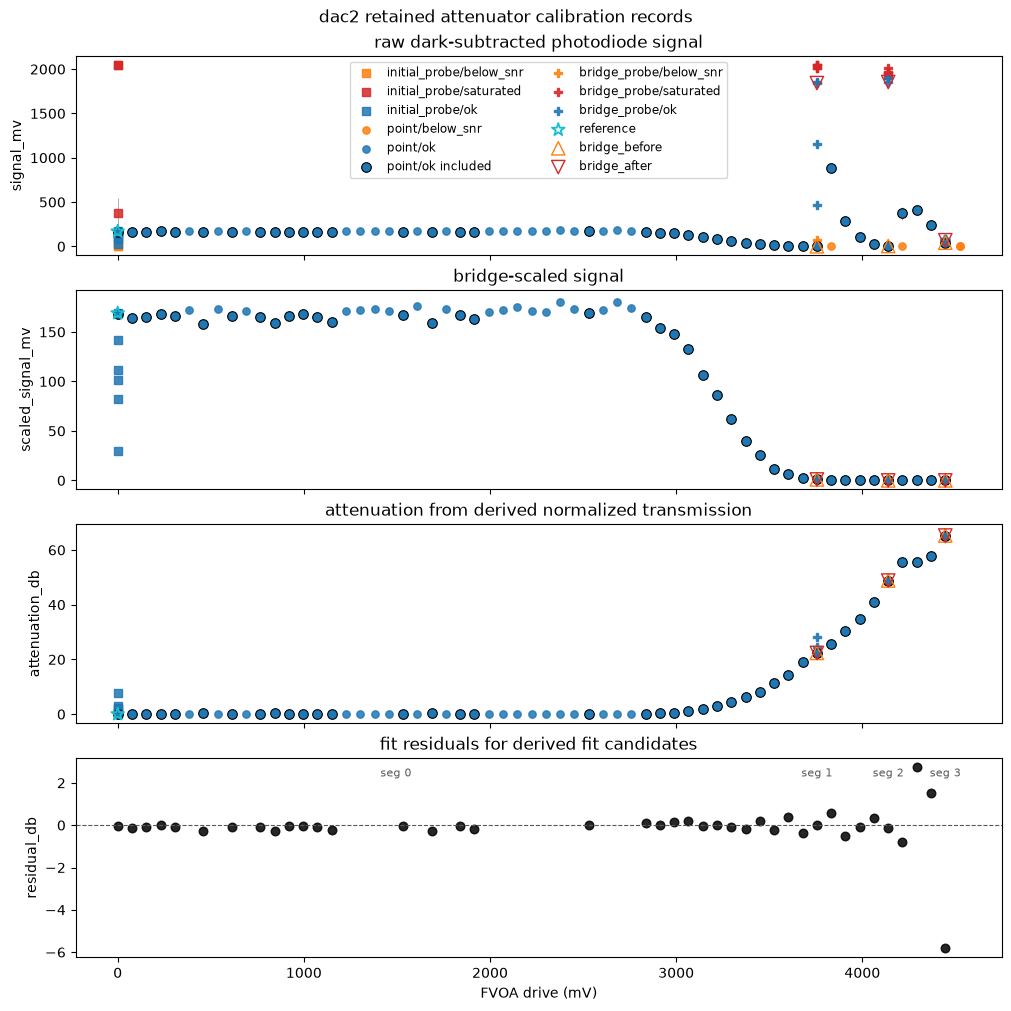

In [14]:
print(embedded)
embedded.bridge_table()
embedded.plot_physical("dac1");
embedded.plot_physical("dac2");



In [25]:
pcb.atten_coeff(LASER)

AttenuatorCoeff(
  dac1=AttenuatorPhysicalCoeff(
  fvoa_50pct_mv=3211.83,
  slope_inv_fvoa_mv=0.0028598,
  max_atten_db=70.8144,
  gain=1.533,
  correction_coeff=(-8.48774, -13.9842, -12.9546, -6.93199, -1.41204, -2.94434),
  rms_db=0.94087
),
  dac2=AttenuatorPhysicalCoeff(
  fvoa_50pct_mv=3204.24,
  slope_inv_fvoa_mv=0.00315759,
  max_atten_db=59.4765,
  gain=1.533,
  correction_coeff=(2.73564, 9.3154, 3.8461, 4.79383, -1.31107, -3.53273),
  rms_db=1.0718
)
)

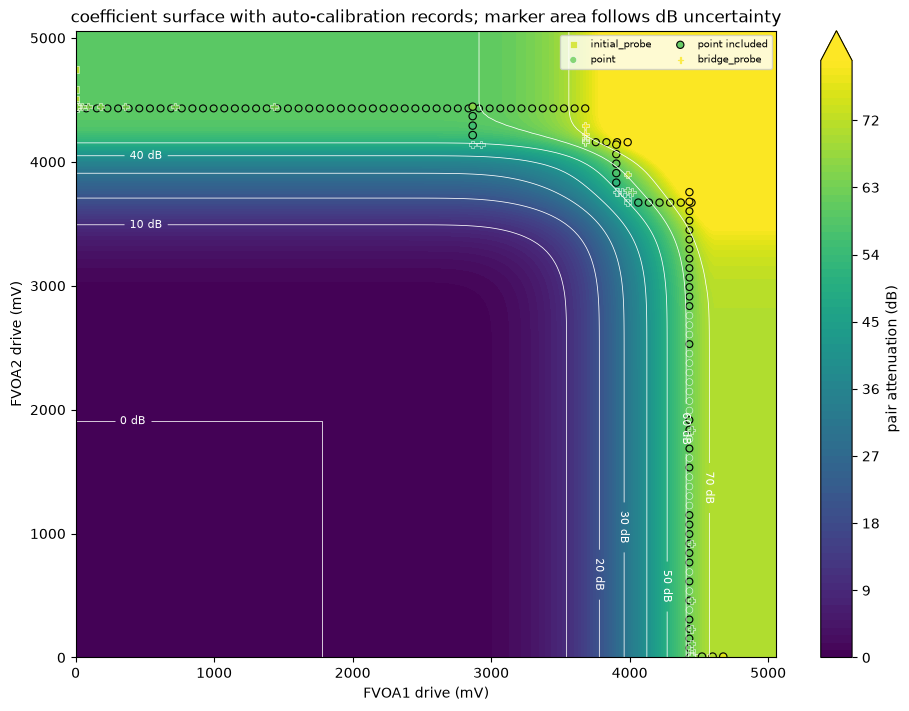

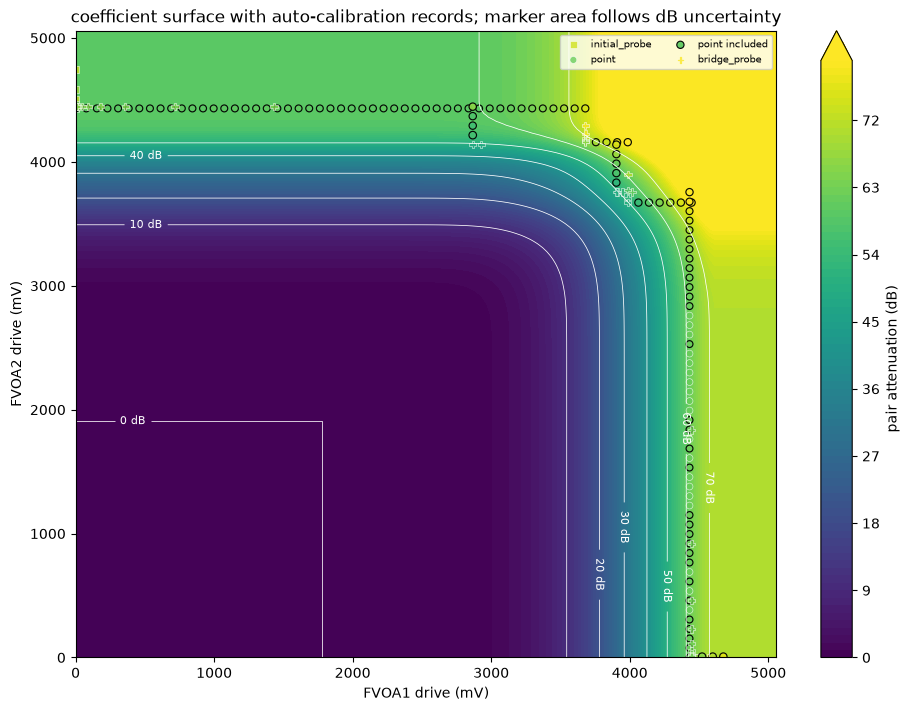

In [16]:
coeff = pcb.atten_coeff(LASER)
embedded.plot_surface(coeff.dac1, coeff.dac2, overlay_records=True)


## Manually verify levels

In [45]:
pcb.pd('yj')
pcb.atten('1028y', value_db=99)
pcb.laser('1028y', value=0.0)
time.sleep(1)
print('OFF', pcb.pd('yj'))
pcb.atten('1028y', value_db=99)
pcb.laser('1028y', value=1.0)
time.sleep(1)
print('Laser 100, atten 99', pcb.pd('yj'))
pcb.atten('1028y', value_db=0)
pcb.laser('1028y', value=0.02)
time.sleep(.5)
print('Laser 2, atten 0', pcb.pd('yj'))
pcb.atten('1028y', value_db=40)
pcb.laser('1028y', value=0.02)
time.sleep(1)
print('Laser 2, atten 20db', pcb.pd('yj'))
pcb.laser('1028y', value=0.0)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=194.979 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=194.979 threshold_mv=10.000 uptime_s=0


OFF PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-30,
  mv=-1.875,
  net_mv=-145.287,
  net_err_mv=7.59,
  power_uw=0,
  power_err_uw=0,
  dark_mv=143.412,
  dark_err_mv=7.59,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.54,
  mean_net_mv=-144.952,
  rms_mv=0.353,
  mean_net_err_mv=7.59,
  min_mv=-2.312,
  max_mv=-0.875,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=441
),
  hk=None
)
Laser 100, atten 99 PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-31,
  mv=-1.938,
  net_mv=-145.35,
  net_err_mv=7.59,
  power_uw=0,
  power_err_uw=0,
  dark_mv=143.412,
  dark_err_mv=7.59,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.712,
  mean_net_mv=-145.125,
  rms_mv=0.26,
  mean_net_err_mv=7.59,
  min_mv=-2.25,
  max_mv=-1.188,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=443
),
  hk=None
)
Laser 2, atten 0 PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=32767,
  mv=2047.

CommandOk(status='ok')

In [10]:
pcb.pd('yj')
pcb.atten('1028y', value_db=99)
pcb.laser('1028y', value=0.0)
time.sleep(1)
pcb.pd('yj')

PCB warning attenuator_clamped: attenuator command exceeded modeled range and was clamped context=requested=99.000 clamped=74.151 uptime_s=0
PCB warning attenuator_clamped: attenuator command exceeded modeled range and was clamped context=requested=99.000 clamped=74.151 uptime_s=0


PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=9038,
  mv=564.875,
  net_mv=566.711,
  net_err_mv=0.374,
  power_uw=3e-05,
  power_err_uw=0,
  dark_mv=-1.836,
  dark_err_mv=0.368,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=565.433,
  mean_net_mv=567.268,
  rms_mv=0.457,
  mean_net_err_mv=0.379,
  min_mv=564.312,
  max_mv=566.188,
  power_uw=3e-05,
  power_err_uw=0
),
  pd_powered=True,
  pd_on_s=1
),
  hk=None
)

## Explore throughput monitoring

The optional message pane displays replies, warnings, and logs from `pcb`.
Throughput packets go directly to collection. The latest 500 log records stay
in the pane; one asyncio task refreshes changed content at most twice per second.

Firmware emits one fresh conversion per channel every **50 ms (20 Hz)**. The
throughput stream does not use the diagnostic 500 ms rolling window or reuse
ADC samples. Missing acquisitions appear as timestamp gaps. The monitor selects source context by
acquisition time; slow actuator and optical responses remain visible.

Binary is the default; JSON is also supported. Channel plus wavelength identifies
the source, including the two 1430 nm lasers. Both encodings carry overrange and
autolevel state. Firmware allows **one autolevel owner**, while both PDs may stream.
Additional manually enabled lasers also affect these readings.

The dashboard refreshes every 0.5 s and shows the latest 600 records (30 seconds
at nominal cadence); collection retains up to 20,000. Calibration uncertainty
is shared between samples and does not average away. Recapture dark after this
cadence change or changing ADC conversion rate. A measured dark supplies the
reading-noise baseline; illuminated shot noise and unmeasured response/route
calibration errors are not included. See `doc/photodiode_notes.md` for the audit.

Route corrections are captured at start. Firmware supplies nominal switch/static
loss defaults, with explicit `pcb.mems_route_loss(...)` settings overriding each
complete path total. Numeric API values are fractions **lost**; use a string
such as `loss="74.1103466 dB"` for large losses. Query effective losses and restart
after a route-calibration change. Stream `laser_route_tx` and `pd_route_tx` are
**transmissions**. Taking a dark or starting calibration stops throughput; it
must be started again explicitly.

For passive external light (including starlight), use:
```python
monitor = pcb.measure_throughput("none", channel=CHANNEL, fiber=FIBER,
                                 autolevel=False, collect=True)
```
This selects the MM/SM return and corrects detected power/error, leaving launch
switches untouched. To route external calibration light too, supply both
`input="yj_cal"` and `output="yj_ao"` (or the corresponding HK labels).
The command prepares ownership before applying the independent launch and return
routes. Unknown emission means source power and throughput remain NaN; PD power,
its error, and detector S/N remain useful. Return defaults are 0.98 MM / 0.60 SM;
per-laser overrides are used only with a known laser. Stop with `monitor.stop()`.


In [103]:
10**(-25/10)*.1*100

0.03162277660168379

In [39]:
static_atten = 25
trans = 0.88 * 0.88 * 10**(-static_atten/10)
pcb.mems_route_loss('yj_laser_to_yj_ao', laser='1028y', loss=f'{float(-10*np.log10(trans))} dB', persist=True)
pcb.mems_route_loss('yj_laser_to_yj_ao').lasers, 1- trans

((NamedValue(name='1028y', value=0.997551),
  NamedValue(name='1270j', value=0.999923),
  NamedValue(name='1430yj', value=0),
  NamedValue(name='1430hk', value=0),
  NamedValue(name='1510h', value=0),
  NamedValue(name='2330k', value=0)),
 0.9975511321799656)

In [91]:
# Start/replace the selected channel. Use one autolevel loop on overlapping light paths.
# Preserve the prior collector if firmware rejects this start.
previous_monitor = globals().get("monitor")
monitor = pcb.measure_throughput(
    LASER,
    fiber=FIBER,
    output=OUTPUT,
    autolevel=True,
    collect=True,
    format="binary",
    off_in_s=3000,
)
if previous_monitor is not None and previous_monitor.channel == monitor.channel:
    previous_monitor._stop_collection()  # Local cleanup after successful replacement.


### Live dashboard (display controls only)

Pan/zoom with the toolbar; **Follow data** restores autoscaling. Pause freezes
only the plot. Closing the figure stops its timer. Collection and hardware
continue. Rerun this cell to replace the display.

The full-width throughput panel shows the power ratio and reported ± total
error. Its right axis shows path loss, `-10 log10(tp)`, in dB. Below it:

- **PD input:** raw ADC input and individual net reading ± error, with the
  400–1600 mV net control band and 2000 mV raw-input ceiling.
- **S/N:** individual PD reading/error and throughput/total error. Calibration
  uncertainty can limit total S/N even with excellent detector S/N. Autolevel
  uses the voltage band, not an S/N threshold.
- **Source and attenuation:** drive current and combined dynamic attenuation.
- **Estimated laser optical output:** µW before dynamic and static attenuation,
  inferred from current calibration; this is not an optical power measurement.
- **Route-corrected optical power:** delivered and detected nW ± error. Delivered
  power includes outbound static loss and dynamic attenuation; detected power
  is divided by the return-path transmission.

Overrange (raw input ≥2000 mV) marks the throughput as a **nominal lower bound**
and path loss as an upper bound. PD/throughput errors and S/N are undefined there.
Nonpositive log values and missing acquisitions appear as gaps. Collection/CSV
preserve signed net voltages, zero-clipped power, errors, flags, and timestamps. Only the
visible record tail is converted per frame; refresh is capped at 4 Hz.

For passive light, the source and throughput panels have no defined values;
the PD input, detected nW, and detector S/N remain available.


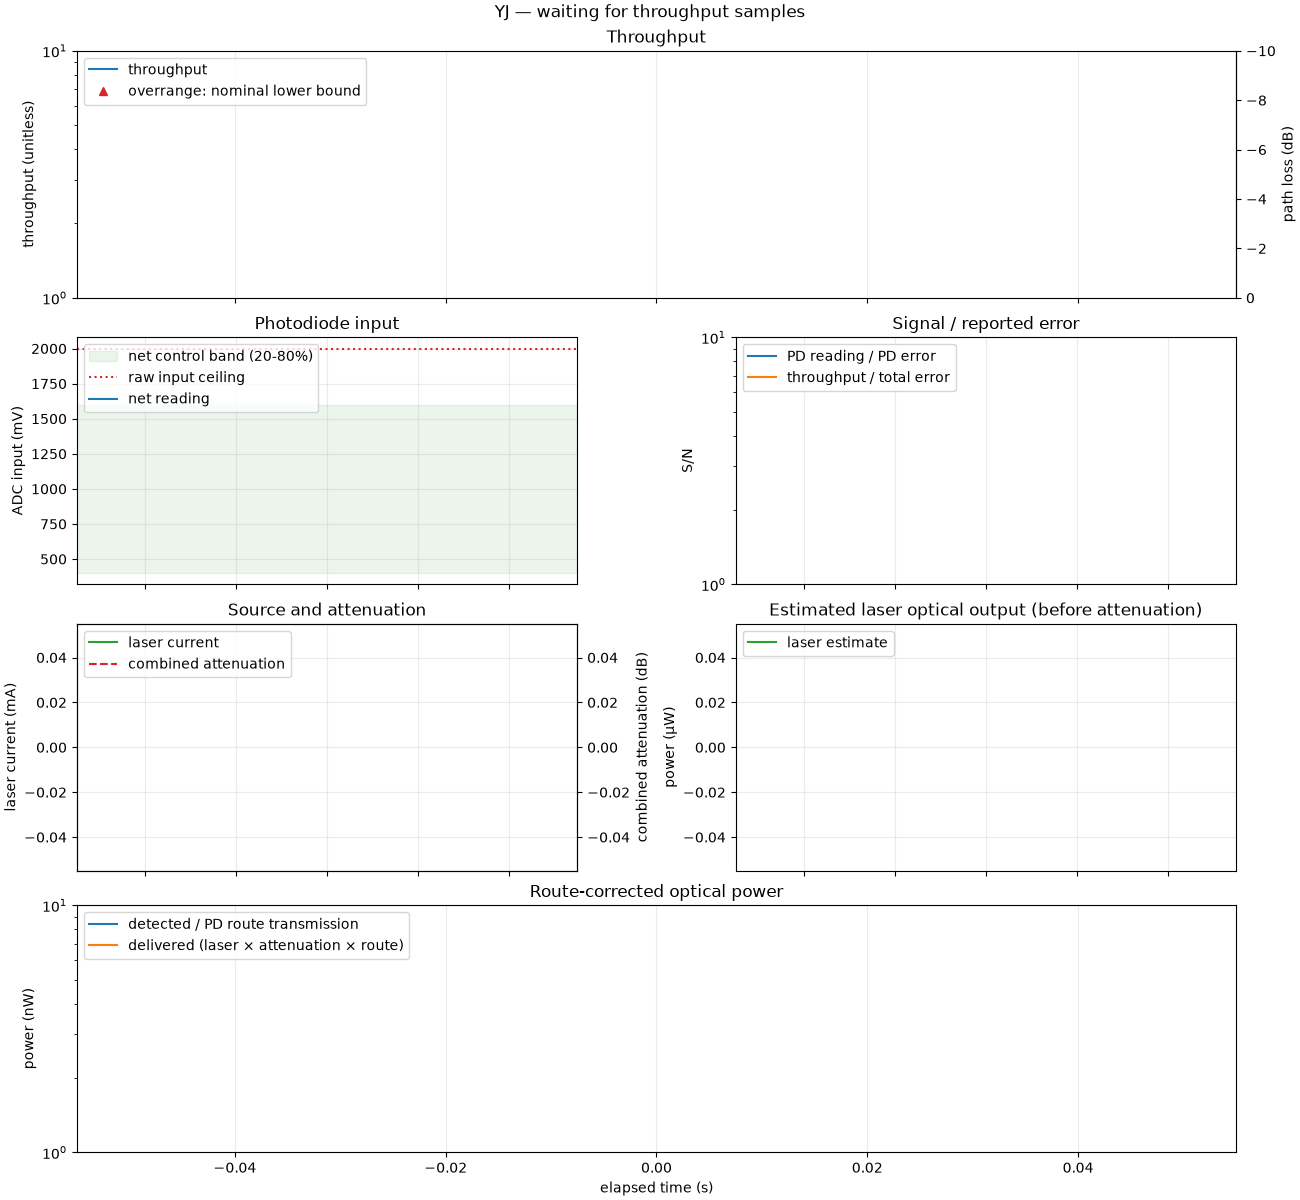

In [94]:
%matplotlib widget

# Keep the animation referenced and remove the old figure/timer on rerun.
if "tp_animation" in globals():
    plt.close(tp_figure)
    for control in tp_controls.children:
        control.close()
    tp_controls.close()
with plt.ioff():
    tp_figure, tp_animation = monitor.plot_live(channel=PD_CHANNEL, max_points=600)

pause_display = widgets.ToggleButton(description="Pause display", value=False)
follow_data = widgets.Button(description="Follow data")

def toggle_display(change):
    if tp_animation.event_source is None or tp_figure.canvas.comm is None:
        return  # The figure has already been closed.
    if change["new"]:
        tp_animation.pause()
    else:
        tp_animation.resume()
    pause_display.description = "Resume display" if change["new"] else "Pause display"

def follow_display(_button):
    for ax in tp_figure.axes:
        ax.set_autoscale_on(True)

pause_display.observe(toggle_display, names="value")
follow_data.on_click(follow_display)
tp_controls = widgets.HBox([pause_display, follow_data])
display(tp_controls, tp_figure.canvas)


In [57]:
pcb.atten_coeff(LASER)

AttenuatorCoeff(
  dac1=AttenuatorPhysicalCoeff(
  fvoa_50pct_mv=3211.83,
  slope_inv_fvoa_mv=0.0028598,
  max_atten_db=70.8144,
  gain=1.533,
  correction_coeff=(-8.48774, -13.9842, -12.9546, -6.93199, -1.41204, -2.94434),
  rms_db=0.94087
),
  dac2=AttenuatorPhysicalCoeff(
  fvoa_50pct_mv=3204.24,
  slope_inv_fvoa_mv=0.00315759,
  max_atten_db=59.4765,
  gain=1.533,
  correction_coeff=(2.73564, 9.3154, 3.8461, 4.79383, -1.31107, -3.53273),
  rms_db=1.0718
)
)

In [98]:
pcb.atten('1028y', value1_db=25, value2_db=35)

AttenuatorState(
  db=59.9594,
  linear=1.0094e-06,
  v1_mv=2526.56,
  v2_mv=2601.49,
  db1=24.9844,
  db2=34.975,
  linear1=0.00317364,
  linear2=0.000318057
)

In [92]:
pcb.laser('1028y', .1)

CommandOk(status='ok')

In [89]:

# pcb is your connected client; this call only queries coefficients.
c = pcb.atten_coeff("1028y").dac1  # select your channel and physical FVOA
coeff = hspcb._atten_coeff_tuple("dac1", c)

mean_fvoa_mv = 3824.0
noise_rms_mv = 7.2
h = 0.1               # numerical derivative step, FVOA-side mV

dac_mv = (mean_fvoa_mv + np.array([-h, 0.0, h])) / c.gain
a_minus, a0, a_plus = hspcb._atten_db_from_coeff(coeff, dac_mv)

slope_db_per_fvoa_mv = (a_plus - a_minus) / (2 * h)
sigma_db = abs(slope_db_per_fvoa_mv) * noise_rms_mv
T0 = 10.0 ** (-a0 / 10.0)
fractional_rms = np.log(10.0) / 10.0 * sigma_db

print(f"Nominal transmission: {T0:.6g}")
print(f"Transmission RMS: {T0 * fractional_rms:.6g}")
print(f"Relative variation: {100 * fractional_rms:.3g}% RMS")


# pcb is your connected client; this call only queries coefficients.
c = pcb.atten_coeff("1028y").dac2  # select your channel and physical FVOA
coeff = hspcb._atten_coeff_tuple("dac2", c)

mean_fvoa_mv = 3942.0
noise_rms_mv = 9.3
h = 0.1               # numerical derivative step, FVOA-side mV

dac_mv = (mean_fvoa_mv + np.array([-h, 0.0, h])) / c.gain
a_minus, a0, a_plus = hspcb._atten_db_from_coeff(coeff, dac_mv)

slope_db_per_fvoa_mv = (a_plus - a_minus) / (2 * h)
sigma_db = abs(slope_db_per_fvoa_mv) * noise_rms_mv
T0 = 10.0 ** (-a0 / 10.0)
fractional_rms = np.log(10.0) / 10.0 * sigma_db

print(f"Nominal transmission: {T0:.6g}")
print(f"Transmission RMS: {T0 * fractional_rms:.6g}")
print(f"Relative variation: {100 * fractional_rms:.3g}% RMS")

Nominal transmission: 0.00593997
Transmission RMS: 0.000533198
Relative variation: 8.98% RMS
Nominal transmission: 0.000641935
Transmission RMS: 8.32927e-05
Relative variation: 13% RMS


In [95]:

# pcb is your connected client; this call only queries coefficients.
c = pcb.atten_coeff("1028y").dac1  # select your channel and physical FVOA
coeff = hspcb._atten_coeff_tuple("dac1", c)

mean_fvoa_mv = 3824.0
noise_rms_mv = 7.2
h = 0.1               # numerical derivative step, FVOA-side mV

dac_mv = (mean_fvoa_mv + np.array([-h, 0.0, h])) / c.gain
a_minus, a0, a_plus = hspcb._atten_db_from_coeff(coeff, dac_mv)

slope_db_per_fvoa_mv = (a_plus - a_minus) / (2 * h)
sigma_db = abs(slope_db_per_fvoa_mv) * noise_rms_mv
T0 = 10.0 ** (-a0 / 10.0)
fractional_rms = np.log(10.0) / 10.0 * sigma_db

print(f"Nominal transmission: {T0:.6g}")
print(f"Transmission RMS: {T0 * fractional_rms:.6g}")
print(f"Relative variation: {100 * fractional_rms:.3g}% RMS")


# pcb is your connected client; this call only queries coefficients.
c = pcb.atten_coeff("1028y").dac2  # select your channel and physical FVOA
coeff = hspcb._atten_coeff_tuple("dac2", c)

mean_fvoa_mv = 3765.0
noise_rms_mv = 8.9
h = 0.1               # numerical derivative step, FVOA-side mV

dac_mv = (mean_fvoa_mv + np.array([-h, 0.0, h])) / c.gain
a_minus, a0, a_plus = hspcb._atten_db_from_coeff(coeff, dac_mv)

slope_db_per_fvoa_mv = (a_plus - a_minus) / (2 * h)
sigma_db = abs(slope_db_per_fvoa_mv) * noise_rms_mv
T0 = 10.0 ** (-a0 / 10.0)
fractional_rms = np.log(10.0) / 10.0 * sigma_db

print(f"Nominal transmission: {T0:.6g}")
print(f"Transmission RMS: {T0 * fractional_rms:.6g}")
print(f"Relative variation: {100 * fractional_rms:.3g}% RMS")

Nominal transmission: 0.00593997
Transmission RMS: 0.000533198
Relative variation: 8.98% RMS
Nominal transmission: 0.00519286
Transmission RMS: 0.000523347
Relative variation: 10.1% RMS


In [11]:
# # Optional snapshot save (does not stop collection). 
from pathlib import Path
import csv

snapshot = monitor.to_recarray()
snapshot_path = Path(f"throughput_{LASER}_{time.strftime('%Y%m%d_%H%M%S')}.csv")
with snapshot_path.open("w", newline="") as output_file:
    writer = csv.writer(output_file)
    writer.writerow(snapshot.dtype.names)
    writer.writerows(snapshot.tolist())
snapshot_path


PosixPath('throughput_1028y_20260915_144520.csv')

In [104]:
# Stop measurement / laser off. Always attempt the explicit zero-level command.
# Errors remain visible, including chained errors if both commands fail.
try:
    monitor.stop()
finally:
    pcb.laser(LASER, stop=True)


In [24]:
# Confirm the selected laser's current state after shutdown.
pcb.laser(LASER)


LaserStatus(
  name='1028y',
  powered=True,
  tec_on_s=1598,
  emit_on_s=None,
  emit_total_s=None,
  temp_c=24.75,
  i_mA=0,
  level=0,
  power_mw=0,
  nominal_nm=1028.01,
  tuned_nm=1028.01,
  tune_nm=0,
  tec_ma=0,
  diode_v=0.2,
  tec_v=0.1,
  off_in_s=None,
  oc_fault=False
)

In [25]:
# Optional display/log cleanup. Run the laser-off cell above first.
if "tp_animation" in globals():
    plt.close(tp_figure)
    for control in tp_controls.children:
        control.close()
    tp_controls.close()
if "message_task" in globals():
    message_task.cancel()
    del message_task
if "message_handler" in globals():
    message_client.logger = previous_logger
    message_logger.removeHandler(message_handler)
    message_handler.close()
    message_output.close()
    del message_handler


In [61]:
monitor.to_recarray()['pd_net_mv'][-100:].std()

np.float64(27.616668504670777)